In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Carregando os dados

In [104]:
dados = pd.read_excel('Dados_Case_2026.xlsx')
dados.head()


,ano,mes,cidade_agrupada,class_segmentos,abertura_empresas
0,2018,1,PORTO ALEGRE,Fisioterapia,1
1,2018,1,grande_sp,Turismo,11
2,2018,1,PORTO ALEGRE,Intermediação,4
3,2018,1,CURITIBA,Eventos,5
4,2018,1,grande_sp,Fisioterapia,6


entendendo

In [75]:
dados['ano'].unique()
dados['cidade_agrupada'].unique()
dados['class_segmentos'].unique()

<StringArray>
[           'Fisioterapia',                 'Turismo',
           'Intermediação',                 'Eventos',
        'Corretor Seguros',             'Odontologia',
        'Outros Arq./Eng.',               'Advocacia',
               'Apoio Adm',                'Medicina',
              'Engenharia',                'Estética',
              'Psicologia',                'Pesquisa',
                  'TI/DEV',   'Trad.NaoEspecializado',
         'Educação Física',        'Corretor Imóveis',
    'Serviços Automotivos',         'Design/Editoria',
          'Representantes',                'Educação',
            'Outros Saúde',       'Mídia e Marketing',
                 'Aluguel',             'Veterinária',
 'Instalação e Manutenção',             'Consultoria',
              'Aquitetura',                 'Limpeza']
Length: 30, dtype: str

agregando por mes

In [76]:
mensal = dados.groupby(['ano', 'mes'])['abertura_empresas'].sum().reset_index()
mensal['data'] = pd.to_datetime(mensal[['ano', 'mes']].assign(dia=1).rename(columns={'ano':'year', 'mes':'month', 'dia':'day'}))
mensal = mensal.sort_values('data').reset_index(drop=True)
mensal.head(12)

,ano,mes,abertura_empresas,data
0,2018,1,9547,2018-01-01
1,2018,2,10217,2018-02-01
2,2018,3,12624,2018-03-01
3,2018,4,12644,2018-04-01
4,2018,5,12796,2018-05-01
5,2018,6,12152,2018-06-01
6,2018,7,12402,2018-07-01
7,2018,8,13766,2018-08-01
8,2018,9,11170,2018-09-01
9,2018,10,12327,2018-10-01


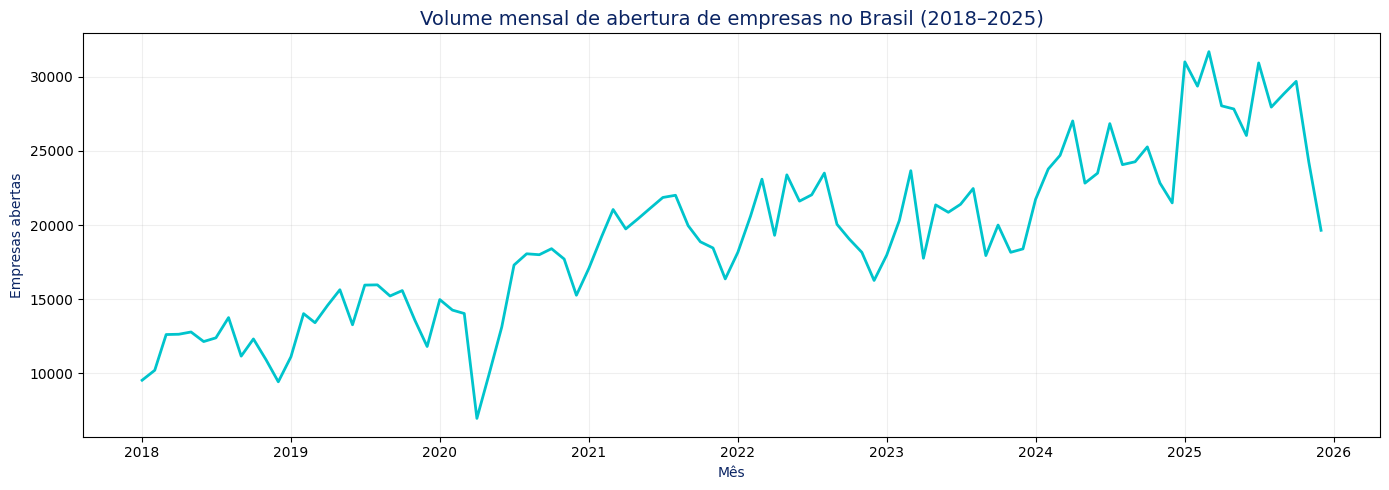

In [99]:
plt.figure(figsize=(14, 5))
plt.plot(mensal['data'], mensal['abertura_empresas'], color='#00C4CC', linewidth=2)
plt.title('Volume mensal de abertura de empresas no Brasil (2018–2025)', fontsize=14, color='#0A2463')
plt.xlabel('Mês', color='#0A2463')
plt.ylabel('Empresas abertas', color='#0A2463')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('grafico_historico.png', dpi=150, bbox_inches='tight')
plt.show()

calculando crescimento medio anual

In [78]:
anual = dados.groupby('ano')['abertura_empresas'].sum()
anual

ano
2018    140009
2019    170235
2020    178132
2021    236230
2022    245241
2023    240302
2024    288281
2025    335196
Name: abertura_empresas, dtype: int64

calculando taxa de crescimento

In [79]:
crescimento = anual.pct_change().dropna()
crescimento

ano
2019    0.215886
2020    0.046389
2021    0.326151
2022    0.038145
2023   -0.020139
2024    0.199661
2025    0.162741
Name: abertura_empresas, dtype: float64

defininfo taxa que vou usar

In [80]:
taxa_crescimento = crescimento[-3:].mean()
print(f"Taxa de crescimento anual usada: {taxa_crescimento:.1%}")

Taxa de crescimento anual usada: 11.4%


Calculando indice sazonal

In [83]:
media_por_mes = mensal.groupby('mes')['abertura_empresas'].mean()
indice_sazonal = media_por_mes / media_por_mes.mean()
indice_sazonal

mes
1     0.926950
2     0.993435
3     1.074965
4     0.955962
5     1.009233
6     0.992957
7     1.104094
8     1.098047
9     1.017394
10    1.041857
11    0.942814
12    0.842292
Name: abertura_empresas, dtype: float64

Agora vou projetar o 2026 e distribuir pelos meses

In [87]:
total_2025 = anual[2025]
total_2026 = total_2025 * (1 + taxa_crescimento)
projecao_mensal = (total_2026 / 12) * indice_sazonal
projecao_mensal.name = 'projecao_2026'
projecao_mensal.round(0).astype(int)

mes
1     28847
2     30915
3     33453
4     29749
5     31407
6     30901
7     34359
8     34171
9     31661
10    32422
11    29340
12    26212
Name: projecao_2026, dtype: int64

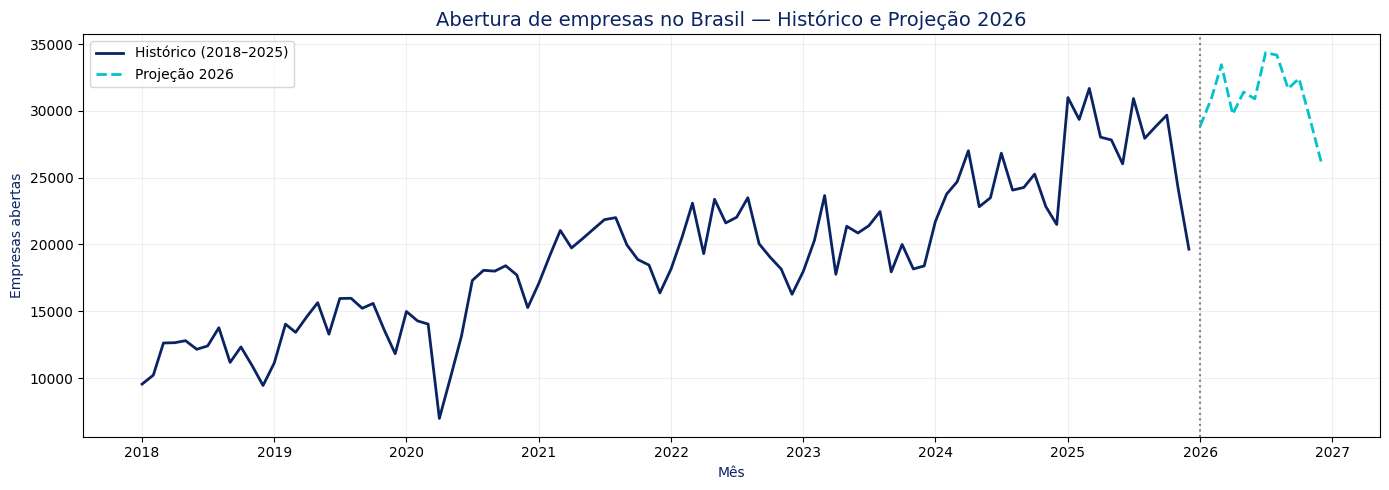

In [100]:
datas_2026 = pd.date_range(start='2026-01-01', periods=12, freq='MS')
datas_2026 = pd.date_range(start='2026-01-01', periods=12, freq='MS')

plt.figure(figsize=(14, 5))
plt.plot(mensal['data'], mensal['abertura_empresas'], color='#0A2463', linewidth=2, label='Histórico (2018–2025)')
plt.plot(datas_2026, projecao_mensal.values, color='#00C4CC', linewidth=2, linestyle='--', label='Projeção 2026')
plt.axvline(x=pd.Timestamp('2026-01-01'), color='gray', linestyle=':', linewidth=1.5)
plt.title('Abertura de empresas no Brasil — Histórico e Projeção 2026', fontsize=14, color='#0A2463')
plt.xlabel('Mês', color='#0A2463')
plt.ylabel('Empresas abertas', color='#0A2463')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('grafico_projecao.png', dpi=150, bbox_inches='tight')
plt.show()

Volatilidade por cidade

In [91]:
cv_cidade = dados.groupby('cidade_agrupada')['abertura_empresas'].agg(['mean', 'std'])
cv_cidade.columns = ['media', 'variacao']
cv_cidade['cv'] = cv_cidade['variacao'] / cv_cidade['media']
cv_cidade.sort_values('cv', ascending=False)

,media,variacao,cv
cidade_agrupada,,,
SAO PAULO,180.800347,249.914557,1.382268
grande_sp,47.846875,56.165276,1.173855
FLORIANOPOLIS,12.189016,13.949450,1.144428
BELO HORIZONTE,36.922917,42.107394,1.140414
CURITIBA,33.912031,38.170823,1.125584
PORTO ALEGRE,20.003489,22.122473,1.105931
outros,261.010764,243.495512,0.932895
RIO DE JANEIRO,44.456250,41.144771,0.925511


Volatilidade por segmento

In [92]:
cv_segmento = dados.groupby('class_segmentos')['abertura_empresas'].agg(['mean', 'std'])
cv_segmento.columns = ['media', 'variacao']
cv_segmento['cv'] = cv_segmento['variacao'] / cv_segmento['media']
cv_segmento.sort_values('cv', ascending=False)

,media,variacao,cv
class_segmentos,,,
Psicologia,83.658793,124.515720,1.488376
Medicina,191.617188,268.577346,1.401635
Fisioterapia,32.675393,44.332970,1.356769
Outros Saúde,56.485640,76.184497,1.348741
Aluguel,18.877688,25.272668,1.338759
Odontologia,54.990874,72.693453,1.321918
Representantes,76.579427,101.224325,1.321821
Educação Física,25.609375,33.040231,1.290162
Engenharia,76.102865,96.214903,1.264274


Calculando a meta de market share anual

In [94]:
market_share_meta = 0.20
meta_anual = total_2026 * market_share_meta
meta_anual.round(0).astype(int)

np.int64(74688)

distribuindo a meta mensalmente

In [95]:
meta_mensal = projecao_mensal * market_share_meta
meta_mensal.round(0).astype(int)

mes
1     5769
2     6183
3     6691
4     5950
5     6281
6     6180
7     6872
8     6834
9     6332
10    6484
11    5868
12    5242
Name: projecao_2026, dtype: int64

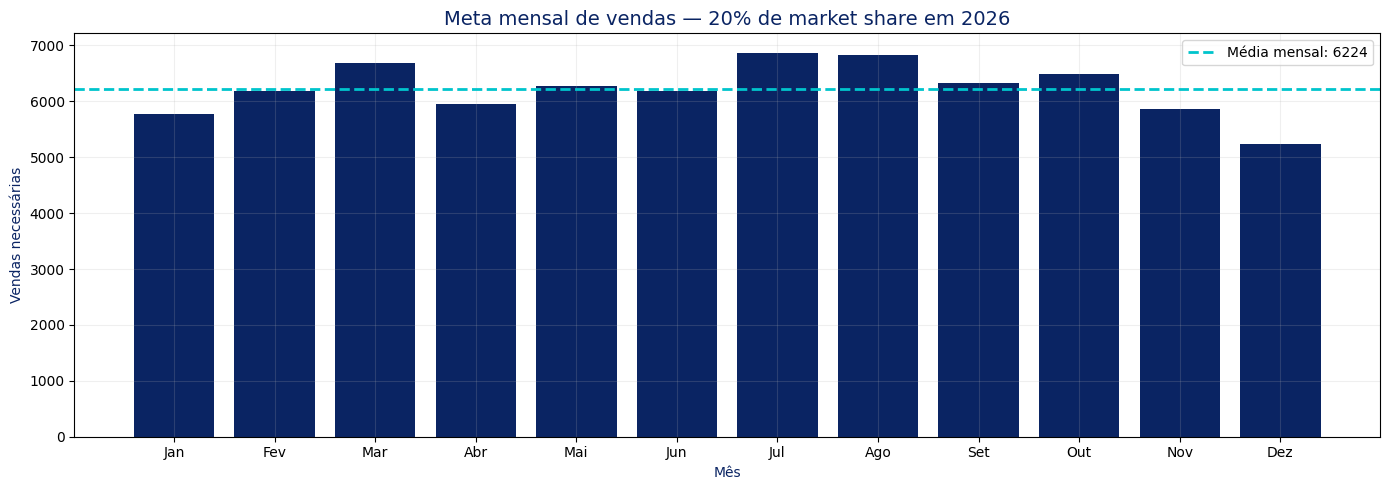

In [101]:
plt.figure(figsize=(14, 5))
plt.bar(meta_mensal.index, meta_mensal.values, color='#0A2463')
plt.axhline(y=meta_mensal.mean(), color='#00C4CC', linestyle='--', linewidth=2, label=f'Média mensal: {meta_mensal.mean():.0f}')
plt.title('Meta mensal de vendas — 20% de market share em 2026', fontsize=14, color='#0A2463')
plt.xlabel('Mês', color='#0A2463')
plt.ylabel('Vendas necessárias', color='#0A2463')
plt.xticks(range(1,13), ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('grafico_meta.png', dpi=150, bbox_inches='tight')
plt.show()
